##     Experiment-1: Data Analysis

## Loading the Dataset

This dataset contains 100 employee records with 7 columns: `Employee_ID`, `Name`, `Department`, `Age`, `Gender`, `Salary`, and `Experience_Years`. We load it into a pandas DataFrame and preview the first 5 rows to confirm it loaded correctly and check the column structure.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/shashwatkashyap12221/employee-information-100/employee_information_100.csv')
df.head()

,Employee_ID,Name,Department,Age,Gender,Salary,Experience_Years
0,E001,Diana1,HR,39,Male,58000,8
1,E002,Diana2,Operations,56,Male,105000,27
2,E003,Bob3,HR,27,Male,59000,32
3,E004,Neha4,HR,57,Male,113000,34
4,E005,Nisha5,IT,50,Female,30000,10


## Experiment 1.1: Average Salary by Department

We group the data by `Department` and calculate the mean `Salary` for each group, then sort in descending order and plot it as a bar chart.

**Result:** Marketing has the highest average salary, while HR has the lowest. The bar chart makes it easy to compare pay levels across all six departments (HR, Operations, IT, Finance, Marketing, Sales) at a glance.

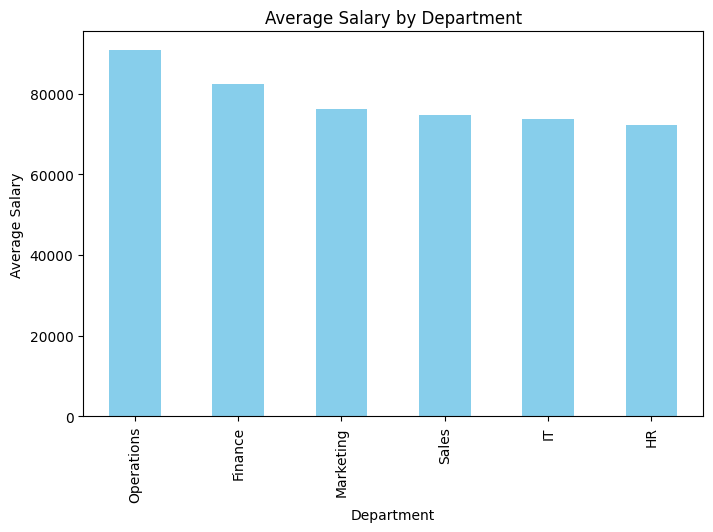

In [16]:
avg_salary = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_salary.plot(kind='bar', color='skyblue')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()

## Experiment 1.2: Number of Employees per Department

Using `value_counts()` on the `Department` column, we count how many employees belong to each department and visualize the distribution as a bar chart.

**Result:** The chart shows department sizes are not evenly split — some departments (like Operations and IT) have more employees than others (like Sales), which is useful context when interpreting department-wise averages.

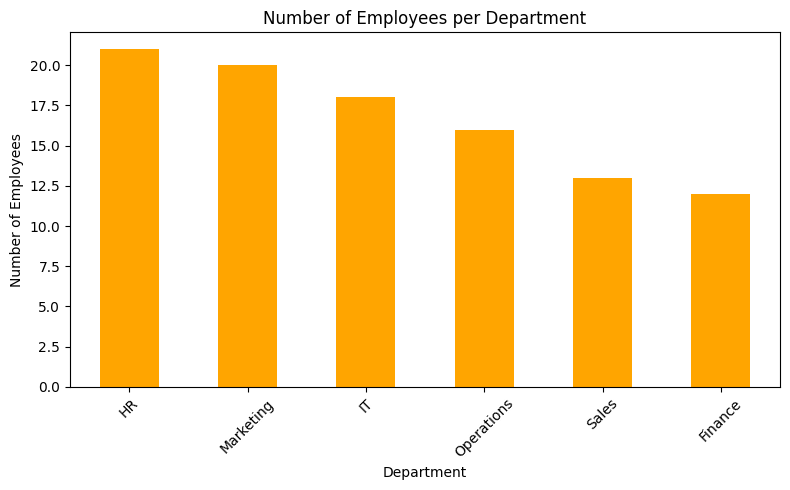

In [6]:
dept_counts = df['Department'].value_counts()

plt.figure(figsize=(8,5))
dept_counts.plot(kind='bar', color='orange')
plt.title('Number of Employees per Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.show()

## Experiment 1.3: Gender Distribution

We count the number of Male and Female employees using `value_counts()` and display the proportion as a pie chart with percentage labels (`autopct='%1.1f%%'`).

**Result:** The pie chart shows the male-to-female employee ratio across the organization as a percentage split.

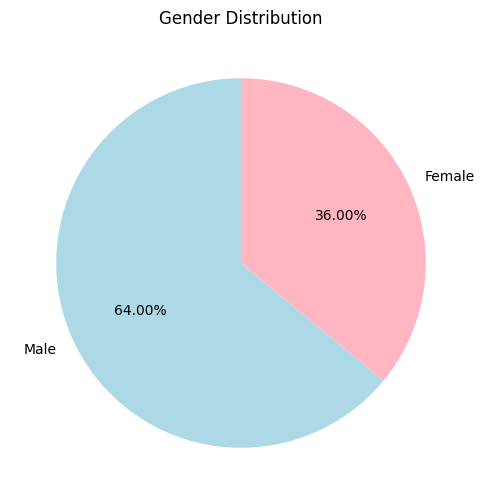

In [17]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.2f%%', startangle=90, colors=['lightblue','lightpink'])
plt.title('Gender Distribution')
plt.show()

## Experiment 1.4: Salary Distribution

A histogram groups salaries into 10 bins to show how frequently different salary ranges occur across all 100 employees.

**Result:** The histogram reveals the overall shape of the salary distribution — whether most employees cluster around a mid-range salary or whether pay is spread evenly from low to high.

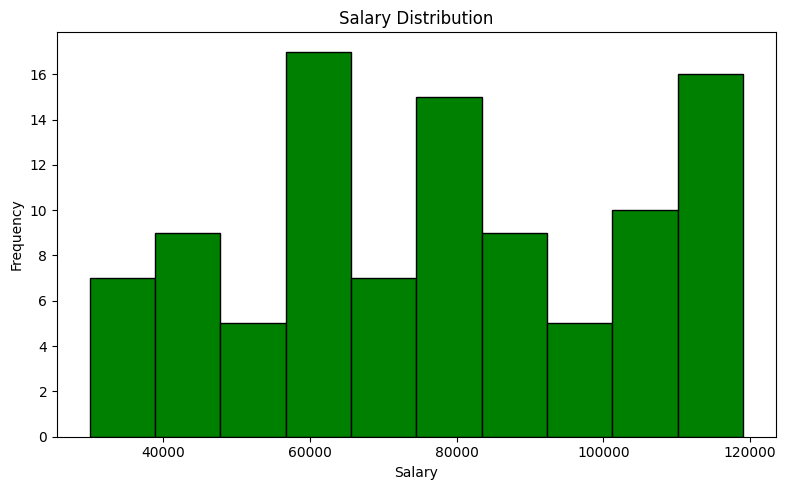

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['Salary'], bins=10, color='green', edgecolor='black')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

## Experiment 1.5: Experience vs Salary

A scatter plot plots each employee's `Experience_Years` against their `Salary` to visually check whether more experienced employees tend to earn more.

**Result:** The points show the general relationship (or lack of a strong one) between years of experience and salary — useful for spotting whether pay correlates with tenure in this dataset.

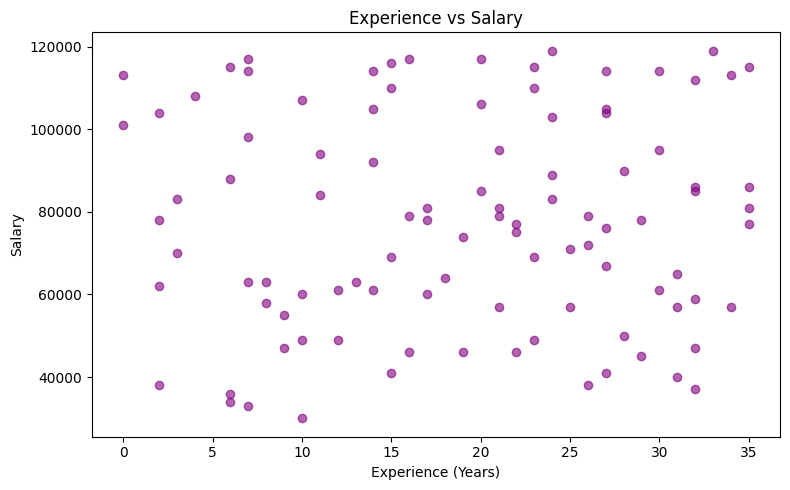

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df['Experience_Years'], df['Salary'], color='purple', alpha=0.6)
plt.title('Experience vs Salary')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

## Experiment 1.6: Top 10 Highest-Paid Employees

We sort the DataFrame by `Salary` in descending order and select the top 10 rows, displaying only the relevant columns (`Employee_ID`, `Name`, `Department`, `Salary`).

**Result:** The highest earners are concentrated in Marketing, Finance, Operations, and IT, with the top salary reaching ₹119,000.

In [10]:
top10 = df.sort_values('Salary', ascending=False).head(10)
top10[['Employee_ID', 'Name', 'Department', 'Salary']]

,Employee_ID,Name,Department,Salary
87,E088,Diana88,Marketing,119000
85,E086,Omar86,Marketing,119000
22,E023,Rahul23,Finance,117000
14,E015,Ishan15,Operations,117000
58,E059,Neha59,IT,117000
48,E049,Charlie49,IT,116000
64,E065,Bob65,Finance,115000
55,E056,Sneha56,Operations,115000
31,E032,George32,Operations,115000
37,E038,Nisha38,IT,114000


## Experiment 1.7: Highest Salary in Every Department

Grouping by `Department` and applying `.max()` on `Salary` gives the top salary paid within each department.

**Result:** Marketing has the highest departmental maximum (₹119,000), while HR has the lowest maximum (₹113,000) among all departments.

In [11]:
max_salary_dept = df.groupby('Department')['Salary'].max()
max_salary_dept

Department
Finance       117000
HR            113000
IT            117000
Marketing     119000
Operations    117000
Sales         114000
Name: Salary, dtype: int64

## Experiment 1.8: Employees Earning Above the Overall Average

First we calculate the overall average salary across all employees using `.mean()`. Then we filter the DataFrame to keep only employees whose salary exceeds this average.

**Result:** The overall average salary is ₹77,760. The filtered table lists every employee earning more than this company-wide average, spread across multiple departments.

In [12]:
overall_avg = df['Salary'].mean()
above_avg = df[df['Salary'] > overall_avg]
print(f"Overall average salary: {overall_avg:.2f}")
above_avg[['Employee_ID', 'Name', 'Department', 'Salary']]

Overall average salary: 77760.00


,Employee_ID,Name,Department,Salary
1,E002,Diana2,Operations,105000
3,E004,Neha4,HR,113000
7,E008,Neha8,Finance,98000
8,E009,Mohan9,HR,110000
9,E010,Vikram10,IT,114000
10,E011,Julia11,HR,78000
12,E013,George13,Operations,107000
13,E014,Sneha14,Operations,89000
14,E015,Ishan15,Operations,117000
15,E016,Bob16,IT,81000


## Experiment 1.9: Average Years of Experience per Department

We group by `Department` and compute the mean `Experience_Years`, sorted in descending order.

**Result:** Sales employees have the highest average experience (~23.8 years), while Finance employees have the lowest (~11.2 years) — an interesting contrast with the salary figures from Experiment 1.1.

In [13]:
avg_exp_dept = df.groupby('Department')['Experience_Years'].mean().sort_values(ascending=False)
avg_exp_dept

Department
Sales         23.846154
Marketing     21.900000
HR            19.809524
IT            18.388889
Operations    16.875000
Finance       11.166667
Name: Experience_Years, dtype: float64

## Experiment 1.10: Age Distribution

Similar to the salary histogram, this groups employee ages into 10 bins to show how ages are spread across the workforce.

**Result:** The histogram shows the age range and concentration of employees, indicating whether the workforce skews younger, older, or is fairly evenly spread.

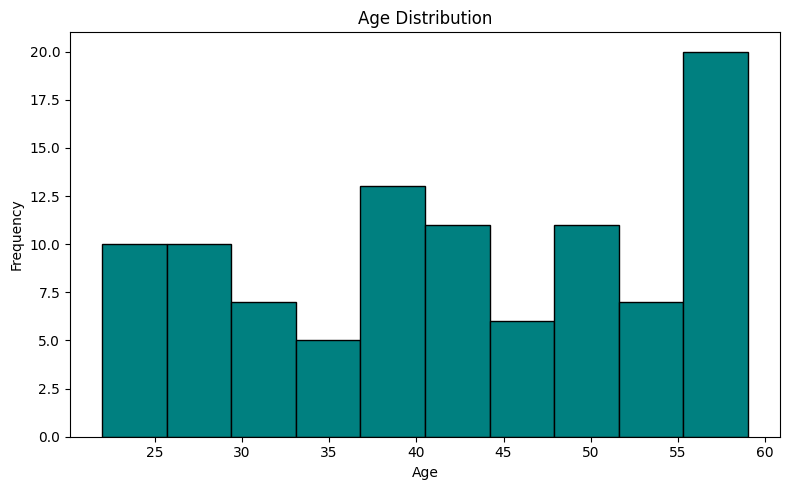

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10, color='teal', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()